# Step 0 : Install the Libraries Required

In [ ]:
%pip install requests numpy matplotlib scipy scikit-learn torch

In [26]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import numpy as np
import requests

Helper Functions to Read Files

In [27]:
#from past labs in EECS4643
def readBiopacResults(filename):
    with open(filename, 'r') as f:
        temp = [l for l in f]
    result = []
    for i in range(0, len(temp)):
        q = temp[i].strip().split()
        if q:
            result.append([float(v) for v in q])

    return np.array(result)

In [28]:
def readCSV(filename):
    """
    Read a CSV file (with a single header row) into a numeric NumPy array.
    """
    with open(filename, 'r') as f:
        temp = [l for l in f]

    result = []
    for i in range(0, len(temp)):
        # Skip header row
        if i == 0:
            continue
        q = temp[i].strip().split(',')
        if q:
            result.append([float(val) for val in q])

    return np.array(result)

# Step 1: Load Public Data
## Load a public data set with ECG data

In [29]:
# Download a public ECG sample and load it as our working dataset
# - Source: NeuroKit demo ECG sampled at 1000 Hz
# - We save it locally as CSV and then parse it into a numeric array

url = 'https://raw.githubusercontent.com/neuropsychology/NeuroKit/master/data/ecg_1000hz.csv'
local_filename = 'sample_ecg_data.csv'
dataset_sampling_rate = 1000  # (Hz)
# Fetch and store the CSV file
response = requests.get(url)
with open(local_filename, 'wb') as f:
    f.write(response.content)

# Load the CSV as a numeric array (skips header, parses comma-separated values)
try:
    data = readCSV(local_filename)
    print(f'Data Shape: {data.shape}')
except Exception as e:
    print(f'Error reading file: {e}')

Data Shape: (50000, 1)


# Step 2: Pre-Process ECG data

In [30]:
def bandpass_filter(data, lowcut, highcut, fs, order=5):
    """
    Apply a zero-phase band-pass filter to emphasize the QRS energy band.

    Parameters
    - data: 1D array of ECG samples
    - lowcut/highcut: passband edges in Hz (typical QRS band ~5–15 Hz)
    - fs: sampling rate in Hz
    - order: Butterworth filter order
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    #Handle not Enough data issue
    padlen = 3 * (max(len(a), len(b)) - 1)
    if data.size <= padlen:
        return data

    y = filtfilt(b, a, data)
    return y

def resample_data(raw_data,original_fs, new_fs=1000):
    if int(original_fs) != new_fs:
        # http://signalsprocessed.blogspot.com/2017/05/resampling-in-python-electric-bugaloo.html
        from scipy.signal import resample_poly
        from math import gcd
        g = gcd(original_fs, int(new_fs))
        up = new_fs // g
        down = int(original_fs) // g
        sig_model = resample_poly(raw_data, up=up, down=down)
        scale_to_orig = original_fs / new_fs
    else:
        sig_model = raw_data
        scale_to_orig = 1.0
    return sig_model

def preprocess_data(raw_data, fs):
    """
    Standardize an ECG channel for analysis.

    Steps
    1) Ensure a 1D float array and resample to 1000 Hz 
    2) Band-pass filter (~5–15 Hz)
    3) normalization: center at 0, unit variance
    """
    # Ensure 1D float array
    x = np.asarray(raw_data)
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(float)

    x = resample_data(x,fs)
    # Band-pass filter
    lowcut = 5
    highcut = 15.0
    filtered = bandpass_filter(x, lowcut, highcut, fs, order=2)
    #normalize
    std = np.std(filtered)
    normalized = (filtered - np.mean(filtered)) / std
    return normalized,x

## Step2.1: Call the functions and plot a result of preprocessing

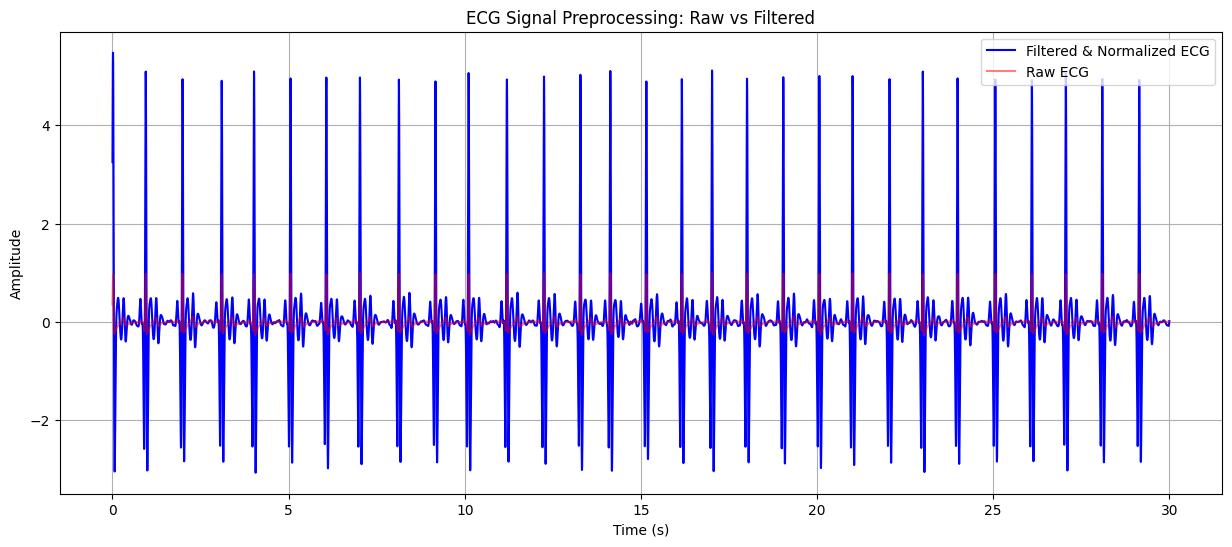

Preprocessing complete: Band-pass (5–15 Hz) and Z-score normalization applied.


In [31]:
# compare raw ECG vs. preprocessed ECG
# - Gray trace: unfiltered raw signal
# - Red  trace: band‑passed, resampled and normalized signal used for detection

ecg_raw = data[:, 0]
ecg_normalized,_ = preprocess_data(ecg_raw, dataset_sampling_rate)

time = np.arange(len(ecg_raw)) / dataset_sampling_rate
time_toDisplay = 30  # seconds to plot

plt.figure(figsize=(15, 6))
plt.plot(time[: time_toDisplay * dataset_sampling_rate], ecg_normalized[: time_toDisplay * dataset_sampling_rate],
         label='Filtered & Normalized ECG', color='blue')

plt.plot(time[: time_toDisplay * dataset_sampling_rate], ecg_raw[: time_toDisplay * dataset_sampling_rate],
         label='Raw ECG', alpha=0.5, color='red')
plt.title('ECG Signal Preprocessing: Raw vs Filtered')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

print('Preprocessing complete: Band-pass (5–15 Hz) and Z-score normalization applied.')

# Step 3: Label the Dataset for training

In [32]:
# Peak labeling
# --------------------------------------------------------------
# Mark the locations of peaks  on ECG ie.  y[i] == 1 indicates a detected peak at sample i and 0 otherwise.
# Outputs
# - `X`: the normalized ECG signal
# - `y`: the labels 

min_rr_sec = 0.2  #sec  minimum RR interval to avoid double counting (seconds)
# Detect peaks on the normalized signal to avoid repeat detections
peaks, _ = find_peaks(ecg_normalized, distance=min_rr_sec*dataset_sampling_rate, height=0.7)

# Create a binary label vector aligned with the full signal
labels_vector = np.zeros(ecg_normalized.shape[0], dtype=int)
labels_vector[peaks] = 1

# Feature (X) and label (y) for downstream use
X = ecg_normalized  # X is common practise for training
y = labels_vector  # y is labels and is common practise for training

# Step 3.1 Display Training label tests to verify correct labelling

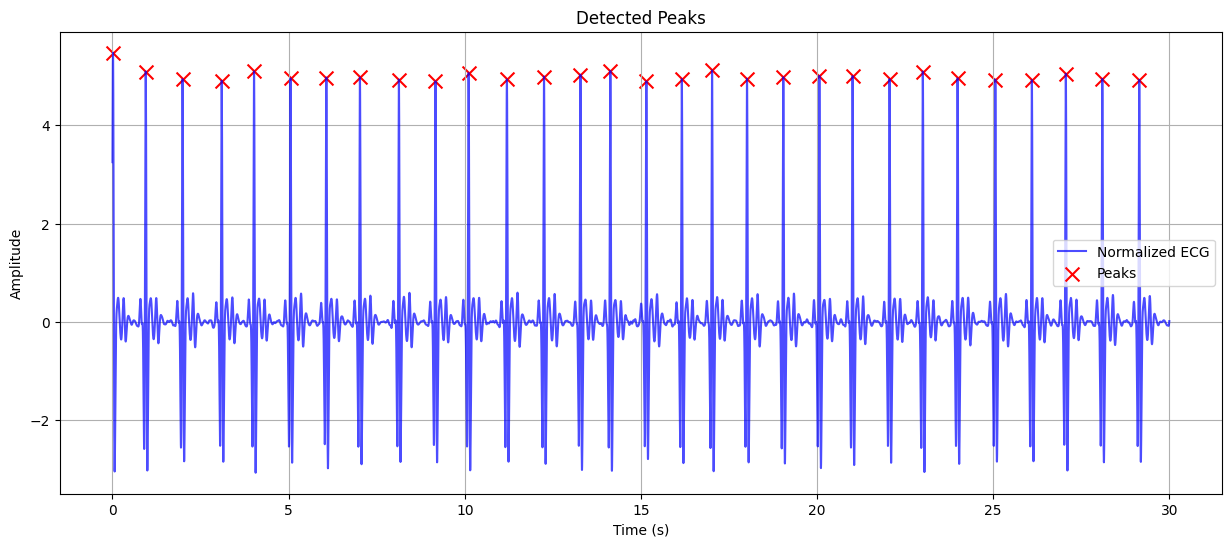

In [33]:
# Visualize detected peaks on the normalized ECG 

duration = 30 #plot first X seconds
max_index = duration * dataset_sampling_rate

# 4) Plot ECG and overlay detected peaks
plt.figure(figsize=(15, 6))
plt.plot(time[:max_index], ecg_normalized[:max_index], label='Normalized ECG', color='blue', alpha=0.7)
plt.scatter(time[peaks[peaks < max_index]], ecg_normalized[peaks[peaks < max_index]], color='red', marker='x', s=100, label='Peaks')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Detected Peaks')
plt.legend()
plt.grid()
plt.show()


# Step 4: train 1D CNN model.

In [34]:
# Sequence labeling model using a 1D CNN
# Train a simple convolutional network that takes the entire ECG segment and predicts, for each sample, whether it belongs to an R-peak (1) or not (0).
#
# Design choices
# - Train/validation split is performed by time (80/20) to respect temporal order.
# - Sequential Convolution-only to make this easy
# - Since Peaks is <<< nonpeaks use BCEWithLogitsLoss, to weight the "positives" with high value 999

#References: https://medium.com/@zergtant/use-weighted-loss-function-to-solve-imbalanced-data-classification-problems-749237f38b75
#References: https://www.codegenes.net/blog/examplebcewithlogitsloss-pytorch/
#References: https://colab.research.google.com/github/ancilcleetus/Time_Series_Project_01_HeartBeatInsight/blob/main/notebooks/Deep_Learning_Methods_for_ECG_Heartbeat_Classification.ipynb


import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

# 1) Train/Val split by time (80/20)
split_idx = int(0.8 *  X.shape[0]) #80% of data set is for training, rest for val.
X_train_np, y_train_np = X[:split_idx], y[:split_idx]
X_val_np,   y_val_np   = X[split_idx:], y[split_idx:]

# 2) Convert to tensors  (unsqueeze since pytorch kept complaining) to have 3 data and Conv1D expects B,C,T data.
X_train_t = torch.tensor(X_train_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
y_train_t = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
X_val_t   = torch.tensor(X_val_np,   dtype=torch.float32).unsqueeze(0).unsqueeze(0)
y_val_t   = torch.tensor(y_val_np,   dtype=torch.float32).unsqueeze(0).unsqueeze(0)

fs_train = dataset_sampling_rate
print("Training Data Sampling Frequency", fs_train)
print("Number of Peaks: ", float(y_train_np.sum()))
print("Data Size: ",len(y_train_np))
class SimpleNet(nn.Module):
    """A compact 1D CNN
    Architecture
    - 1 -> 32 -> 64 -(Dropout)->1x1 conv
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=7, padding=3), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv1d(64, 1, kernel_size=1)  # logits per time sample
        )
    def forward(self, x):  #since it is a simple sequential net.. just return the output
        return self.net(x) 


model = SimpleNet()
## Make the weight of positives super high.
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(999))
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training loop
train_acc_history, val_acc_history = [], [] #logging arraysto Store output, for graphs
train_loss_history, val_loss_history = [], []  #logging arraysto Store output, for graphs
epochs = 125 # how many training runs.
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    logits_train = model(X_train_t)  # (1,1,T_train)
    loss = criterion(logits_train, y_train_t)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        preds_train = (logits_train.sigmoid() >= 0.5).cpu().numpy().astype(int).reshape(-1)
        train_acc = accuracy_score(y_train_np, preds_train)

    model.eval()
    with torch.no_grad():
        logits_val = model(X_val_t)
        val_loss = criterion(logits_val, y_val_t).item()
        preds_val = (logits_val.sigmoid() >= 0.5).cpu().numpy().astype(int).reshape(-1)
        val_acc = accuracy_score(y_val_np, preds_val)

    train_loss_history.append(loss.item())
    val_loss_history.append(val_loss)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f'Epoch {epoch+1:02d}/{epochs} — loss: {loss.item():.4f}  acc: {train_acc:.4f}  val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}')

# 5) Final accuracy on the validation timeline (per-sample)
y_pred = preds_val  # carried forward for evaluation cell

Training Data Sampling Frequency 1000
Number of Peaks:  40.0
Data Size:  40000
Epoch 01/125 — loss: 1.4736  acc: 0.0366  val_loss: 1.2240  val_acc: 0.0010
Epoch 02/125 — loss: 1.2187  acc: 0.0076  val_loss: 1.0994  val_acc: 0.0010
Epoch 03/125 — loss: 1.0906  acc: 0.0120  val_loss: 1.0282  val_acc: 0.0010
Epoch 04/125 — loss: 1.0204  acc: 0.0192  val_loss: 0.9833  val_acc: 0.0010
Epoch 05/125 — loss: 0.9796  acc: 0.0299  val_loss: 0.9498  val_acc: 0.0010
Epoch 06/125 — loss: 0.9586  acc: 0.0491  val_loss: 0.9250  val_acc: 0.0862
Epoch 07/125 — loss: 0.9144  acc: 0.0784  val_loss: 0.9064  val_acc: 0.1238
Epoch 08/125 — loss: 0.9059  acc: 0.1131  val_loss: 0.8906  val_acc: 0.1616
Epoch 09/125 — loss: 0.8890  acc: 0.1449  val_loss: 0.8773  val_acc: 0.1856
Epoch 10/125 — loss: 0.8804  acc: 0.1719  val_loss: 0.8655  val_acc: 0.2028
Epoch 11/125 — loss: 0.8691  acc: 0.1999  val_loss: 0.8550  val_acc: 0.2178
Epoch 12/125 — loss: 0.8553  acc: 0.2279  val_loss: 0.8454  val_acc: 0.2324
Epoch 13/

# Step 5: Visualize the Training and Eval Results

--- Per-sample Confusion Matrix ---
[[9600  390]
 [   0   10]]

--- Per-sample Classification Report ---
              precision    recall  f1-score   support

 Non-Complex       1.00      0.96      0.98      9990
     Complex       0.03      1.00      0.05        10

    accuracy                           0.96     10000
   macro avg       0.51      0.98      0.51     10000
weighted avg       1.00      0.96      0.98     10000


--- General Outputs ---

Validation Accuracy: 0.9610
Missed Peaks: 0.0000
False Positives: 0.0390


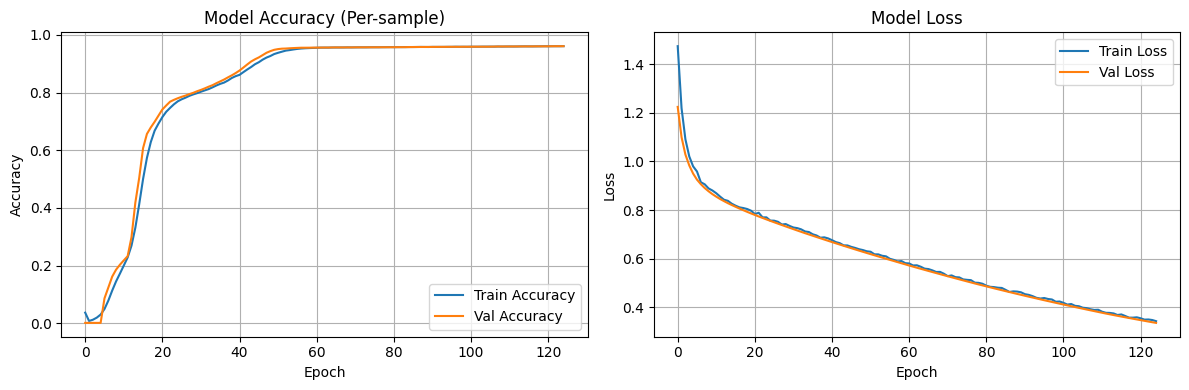

In [35]:
# Validation and Visualization
# ---------------------------

from sklearn.metrics import confusion_matrix, classification_report

#Reference: https://www.geeksforgeeks.org/deep-learning/how-to-visualize-training-progress-in-pytorch/?utm_source=copilot.com
#Reference: https://discuss.pytorch.org/t/plotting-training-and-accuracy-and-loss-after-training-completion/195427/2
cm = confusion_matrix(y_val_np, y_pred)
tn, fp, fn, tp = cm.ravel()
print("--- Per-sample Confusion Matrix ---")
print(cm)
print("\n--- Per-sample Classification Report ---")
print(classification_report(y_val_np, y_pred, target_names=['Non-Complex', 'Complex']))
print("\n--- General Outputs ---")
print(f'\nValidation Accuracy: {val_acc:.4f}')
false_negatives = fn / (fn + tp)
false_positives = fp / (fp + tn)

print(f'Missed Peaks: {false_negatives:.4f}')
print(f'False Positives: {false_positives:.4f}')


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(val_acc_history,   label='Val Accuracy')
plt.title('Model Accuracy (Per-sample)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history,   label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()


# Step 6: Define Pipeline Method to lerage trained model

In [52]:
def predict_complexes(sig_model, sampling_rate=1000, min_rr_sec=0.2, proba_threshold=0.5):
    """
    Detect R-peaks using the trained sequence model (1D CNN).

    Pipeline
    1) Run the CNN to obtain a probability per sample (after sigmoid).
    2) Peak-pick the probability sequence with a physiological minimum RR interval.
    """
    # 3) Run the CNN to get per-sample probabilities
    import torch
    model.eval()
    x_t = torch.tensor(sig_model, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # just like in training
    device = next(model.parameters()).device
    with torch.no_grad():
        proba = model(x_t.to(device)).sigmoid().cpu().numpy().reshape(-1)

    # 4) Peak picking on probability sequence
    distance_samples = int(min_rr_sec * sampling_rate)  # apply RR at model rate
    pred_rel, props = find_peaks(proba, distance=distance_samples, height=proba_threshold)
    
    # 5) Map indices back to original signal index space if resampled
    #pred_abs = np.clip(np.round(pred_rel * scale_to_orig).astype(int), 0, len(raw_data_array) - 1)
    return pred_rel

# Step 7: Call the model prediction interface

In [54]:
lab3_Results = readBiopacResults('./Lab-03-L05_ayesha.txt')
sample_rate = 800
lab3_results_size = lab3_Results.shape[0] / sample_rate
lab3_Results=lab3_Results[:, 0]
print(f'Duration (s): {lab3_results_size:.2f}')

# 1) Preprocess data
fs_train=1000
sig_model,resampled_input = preprocess_data(lab3_Results, sample_rate)
detected_indices = predict_complexes(sig_model)
print(f'Detected {len(detected_indices)} peaks in the test segment.')

Duration (s): 163.70
Detected 181 peaks in the test segment.


# Step 8 : Plot the output

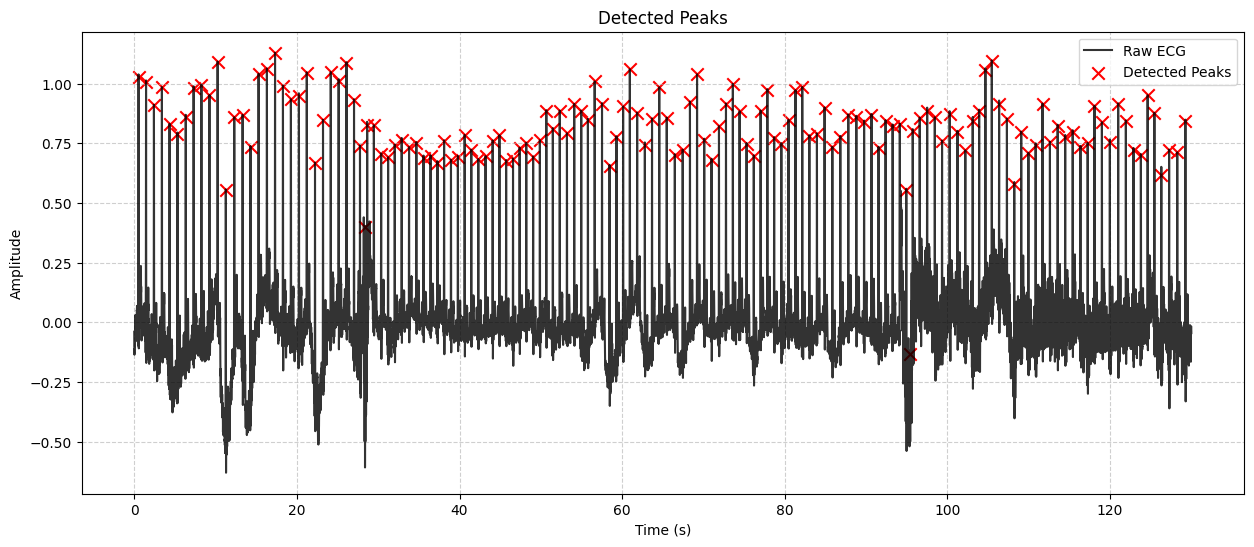

In [55]:
duration_sec = 130
n = min(int(duration_sec * fs_train), len(lab3_Results))

# Build time and signal slices
time_segment = np.arange(n) / fs_train
signal_segment = resampled_input[:n]

#Detected indices to the displayed window
filtered_detections = detected_indices[(detected_indices >= 0) & (detected_indices < n)]

# Plot
plt.figure(figsize=(15, 6))
plt.plot(time_segment, signal_segment, label='Raw ECG', color='black', alpha=0.8)

# Overlay detected complexes
if filtered_detections.size > 0:
    plt.scatter(time_segment[filtered_detections], signal_segment[filtered_detections], color='red', marker='x', s=80, label='Detected Peaks')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Detected Peaks')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()